# A/B Testing: Article Recommendation System

### Evaluating the Impact of Article Recommendations on User Engagement



## Problem Statement

A technology blog has added an article recommendation feature at the end of each article. The goal is to find out whether this feature can encourage users to read more articles.

An A/B test is conducted for 20 days using two groups:

- **Origin**: users who do not see the recommendation feature.
- **Varian**: users who see the recommendation feature.

The main metric used in this analysis is `articles_read`, which represents the number of articles read by a user in one session.

## Objective

The objective of this analysis is to determine whether the article recommendation feature can increase the number of articles read by users.

In [1]:
import random
import string
import numpy as np
import pandas as pd
import scipy.stats as stats

In [2]:
random_state = np.random.default_rng(45)
np.random.seed(45)

daily_users = 104
n_days = 20

n_varian = int(daily_users * n_days * np.random.uniform(0.98, 1.02))
n_origin = int(n_varian * np.random.uniform(0.96, 0.98))

data_origin = stats.poisson.rvs(
    mu=4.7,
    size=n_origin,
    random_state=random_state
)

data_varian = stats.poisson.rvs(
    mu=5.3,
    size=n_varian,
    random_state=random_state
)

In [3]:
def create_unique_user_ids(num_users):
    user_ids = []

    while len(user_ids) < num_users:
        new_id = ''.join(
            random.choices(
                string.ascii_uppercase + string.digits,
                k=10
            )
        )

        if new_id not in user_ids:
            user_ids.append(new_id)

    return user_ids

In [4]:
user_ids = create_unique_user_ids(n_origin + n_varian)

origin_df = pd.DataFrame({
    'user_id': user_ids[:n_origin],
    'user_type': 'origin',
    'articles_read': data_origin
})

varian_df = pd.DataFrame({
    'user_id': user_ids[n_origin:],
    'user_type': 'varian',
    'articles_read': data_varian
})

df_articles = pd.concat([origin_df, varian_df])
df_articles = df_articles.sample(frac=1).reset_index(drop=True)

df_articles.head()

,user_id,user_type,articles_read
0,X9J486QPA4,origin,5
1,IYP55AKA70,origin,6
2,QQWN7LXK08,origin,4
3,W3N6X28WPQ,origin,7
4,QR20JLC7TB,varian,5


In [5]:
df_articles.groupby('user_type')['articles_read'].agg(['count', 'mean'])

,count,mean
user_type,,
origin,2058,4.719631
varian,2120,5.377830


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

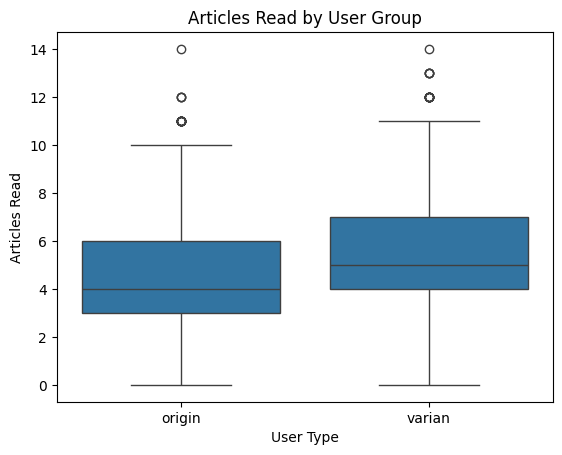

In [7]:
sns.boxplot(
    data=df_articles,
    x='user_type',
    y='articles_read'
)

plt.title('Articles Read by User Group')
plt.xlabel('User Type')
plt.ylabel('Articles Read')
plt.show()

## Hypothesis Testing

To determine whether the difference in the number of articles read is statistically significant, a two-sample t-test is performed.

- **H0 (Null Hypothesis):** There is no difference in the average number of articles read between the two groups.
- **H1 (Alternative Hypothesis):** There is a difference in the average number of articles read between the two groups.

A significance level of 5% 

In [8]:
origin_data = df_articles[df_articles['user_type'] == 'origin']['articles_read']
varian_data = df_articles[df_articles['user_type'] == 'varian']['articles_read']

t_stat, p_value = stats.ttest_ind(
    origin_data,
    varian_data,
    equal_var=False
)

print('t-statistic:', t_stat)
print('p-value:', p_value)

t-statistic: -9.475884016231094
p-value: 4.306193625382671e-21


The p-value is smaller than the significance level of 0.05. Therefore, the null hypothesis is rejected.

This indicates that there is a statistically significant difference in the average number of articles read between the Origin and Varian groups.

In [9]:
alpha = 0.05

if p_value < alpha:
    print('Reject the null hypothesis.')
else:
    print('Fail to reject the null hypothesis.')

Reject the null hypothesis.


## Business Interpretation

The Varian group recorded a higher average number of articles read than the Origin group.

- Origin: 4.72 articles per session
- Varian: 5.38 articles per session
- Difference: 0.66 articles per session

The statistical test also shows that this difference is significant, with a p-value of 4.31 × 10⁻²¹, which is well below the 0.05 significance level.

Based on the simulated A/B test, the article recommendation feature is associated with higher user engagement in terms of articles read.

## Conclusion

The A/B test results show a statistically significant difference in the number of articles read between the two groups.

Users in the Varian group read an average of 5.38 articles per session, compared with 4.72 articles in the Origin group. Based on the simulated experiment, the article recommendation feature is associated with higher user engagement.